# Load an MLP model and convert it to ONNX file
Please take the following steps before running this notebook
1. clone the repo by running `git clone https://github.com/abidihaider/RealTimeAlignment.git`
2. check to the develop branch of the repo
3. run `python setup.py develop`

In [1]:
import os
import sys
from time import time
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('results/throughputs_new.csv')

In [44]:
df

,device,gpu_id,matmul_precision,on_gpu,batch_size,n_runs,ms_per_event
0,cuda,0,high,False,1,20000,0.586551
1,cuda,0,high,True,1,20000,0.550790
2,cuda,0,high,False,2,20000,0.312752
3,cuda,0,high,True,2,20000,0.293807
4,cuda,0,high,False,4,20000,0.136161
...,...,...,...,...,...,...,...
124,cpu,0,medium,False,256,20000,0.058874
125,cpu,0,medium,False,384,20000,0.071727
126,cpu,0,medium,False,512,20000,0.070116
127,cpu,0,medium,False,768,20000,0.085022


## CUDA

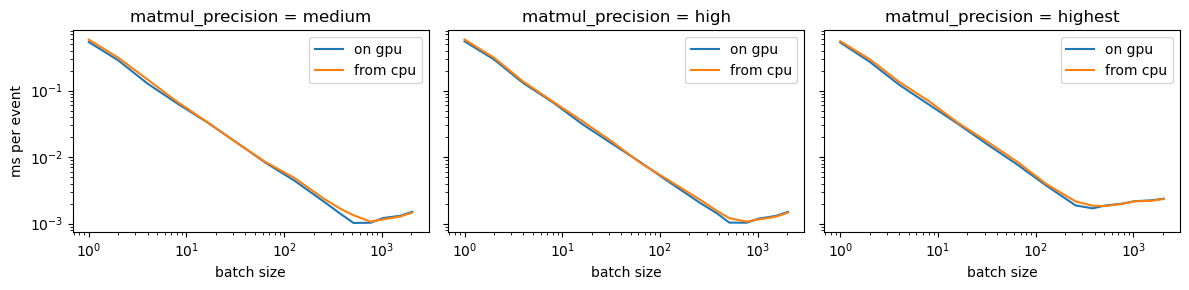

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

df_cuda = df[df.device == 'cuda']

batch_size = df_cuda['batch_size'].unique()

for i, (matmul_precision, ax) in enumerate(zip(['medium', 'high', 'highest'], axes)):
    df_temp = df_cuda[df_cuda.matmul_precision == matmul_precision]

    for on_gpu in [True, False]:
        label = 'on gpu' if on_gpu else 'from cpu'
        ax.plot(batch_size, df_temp[df_temp.on_gpu == on_gpu].ms_per_event, label=label)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel('batch size')
    if i == 0:
        ax.set_ylabel('ms per event')
    ax.legend()
    ax.set_title(f'matmul_precision = {matmul_precision}')
fig.tight_layout()

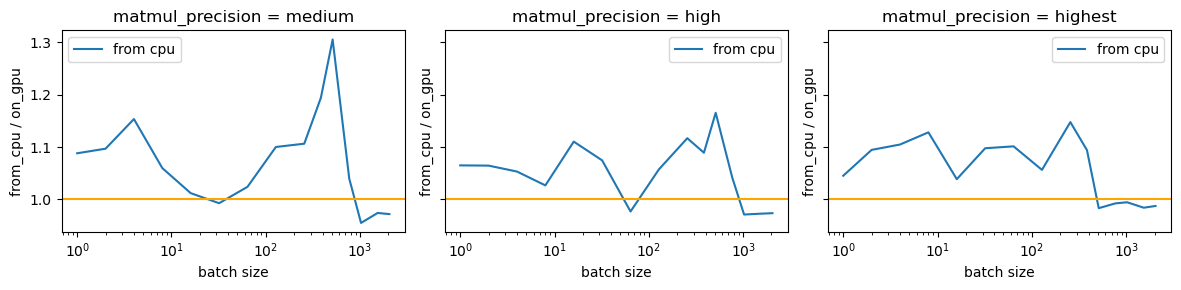

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

df_cuda = df[df.device == 'cuda']

batch_size = df_cuda['batch_size'].unique()

for matmul_precision, ax in zip(['medium', 'high', 'highest'], axes):
    df_temp = df_cuda[df_cuda.matmul_precision == matmul_precision]

    from_cpu = df_temp[df_temp.on_gpu == False].ms_per_event.values
    on_gpu = df_temp[df_temp.on_gpu == True].ms_per_event.values
    ax.plot(batch_size, from_cpu / on_gpu, label=label)
    # ax.set_yscale('log')
    ax.axhline(1, color='orange')
    ax.set_xscale('log')
    ax.set_xlabel('batch size')
    ax.set_ylabel('from_cpu / on_gpu')
    ax.legend()
    ax.set_title(f'matmul_precision = {matmul_precision}')
fig.tight_layout()

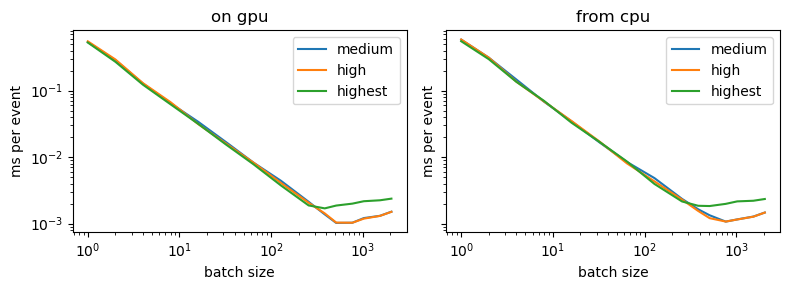

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

df_cuda = df[df.device == 'cuda']

batch_size = df_cuda['batch_size'].unique()

for on_gpu, ax in zip([True, False], axes):
    df_temp = df_cuda[df_cuda.on_gpu == on_gpu]
    
    title = 'on gpu' if on_gpu else 'from cpu'
    
    for matmul_precision in ['medium', 'high', 'highest']:
        ax.plot(batch_size, df_temp[df_temp.matmul_precision == matmul_precision].ms_per_event, label=matmul_precision)
    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel('batch size')
    ax.set_ylabel('ms per event')
    ax.legend()
    
    ax.set_title(f'{title}')
fig.tight_layout()

## CPU vs GPU

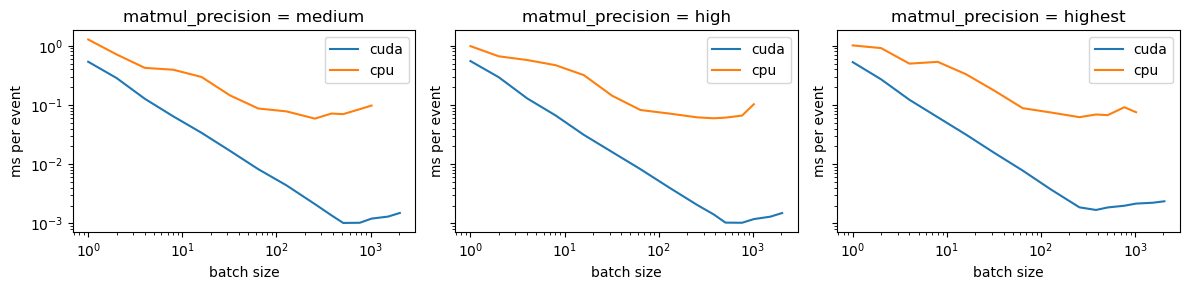

In [43]:
df_cuda = df[df.device == 'cuda']
df_cpu = df[df.device == 'cpu']

batch_size_cuda = df_cuda['batch_size'].unique()
batch_size_cuda = df_cpu['batch_size'].unique()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for matmul_precision, ax in zip(['medium', 'high', 'highest'], axes):
    df_temp_cuda = df_cuda[(df_cuda.matmul_precision == matmul_precision) & (df_cuda.on_gpu == True)]
    df_temp_cpu = df_cpu[df_cpu.matmul_precision == matmul_precision]

    ax.plot(df_temp_cuda['batch_size'], df_temp_cuda.ms_per_event.values, label='cuda')
    ax.plot(df_temp_cpu['batch_size'], df_temp_cpu.ms_per_event.values, label='cpu')
    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel('batch size')
    ax.set_ylabel('ms per event')
    ax.legend()
    ax.set_title(f'matmul_precision = {matmul_precision}')
fig.tight_layout()